In [18]:
import h5py
import numpy as np
import faiss
import pandas as pd

import seaborn
import os
import matplotlib.pyplot as plt

In [19]:
mouse_h5 = '/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/mouse_embeddings_maxpooling.h5'
human_h5 = '/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/human_embeddings_maxpooling.h5'

mouse_outlierstxt = '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_mus.txt'
human_outlierstxt = '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_human.txt'

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def clean_uniprot(id_str):
    if '|' in id_str:
        return id_str.split('|')[1]
    return id_str

outlier_files = [
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_mouse.txt',
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_human.txt'
]

all_outlier_ids = []
for f_path in outlier_files:
    with open(f_path, 'r') as f:
        for line in f:
            cid = clean_uniprot(line.strip())
            if cid:
                all_outlier_ids.append(cid)

unique_outliers = list(set(all_outlier_ids))
print(f"Nombre d'outliers chargés : {len(unique_outliers)}")

Nombre d'outliers chargés : 786


In [24]:
fasta_files = [
    '/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa',
    '/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000589_10090.fa'
]

all_lengths_dict = {}

for fasta_path in fasta_files:
    with open(fasta_path, 'r') as f:
        current_id = None
        current_seq_len = 0
        for line in f:
            line = line.strip()
            if not line: continue
            if line.startswith(">"):
                if current_id:
                    all_lengths_dict[current_id] = current_seq_len
                # Extraction propre de l'ID entre les pipes | |
                full_id = line.split()[0][1:]
                current_id = full_id.split('|')[1] if '|' in full_id else full_id
                current_seq_len = 0
            else:
                current_seq_len += len(line)
        if current_id: # Pour la dernière séquence
            all_lengths_dict[current_id] = current_seq_len



In [37]:
import numpy as np

# 2. Extraire les longueurs
outlier_lengths = [all_lengths_dict[pid] for pid in unique_outliers if pid in all_lengths_dict]
proteome_lengths = list(all_lengths_dict.values())

# 3. Créer le DataFrame pour le graphique
df_plot = pd.concat([
    pd.DataFrame({'Length': proteome_lengths, 'Group': 'Full Proteome'}),
    pd.DataFrame({'Length': outlier_lengths, 'Group': 'Outliers (Max-Pooling)'})
])

# Statistiques pour le rapport
# On calcule les moyennes ici
avg_proteome = np.mean(proteome_lengths)
avg_outliers = np.mean(outlier_lengths)

print(f"\n--- STATS DE LONGUEUR ---")
print(f"Nombre d'outliers : {len(outlier_lengths)}")
print(f"Moyenne Proteome : {avg_proteome:.2f} AA")
print(f"Moyenne Outliers : {avg_outliers:.2f} AA")



--- STATS DE LONGUEUR ---
Nombre d'outliers : 786
Moyenne Proteome : 547.00 AA
Moyenne Outliers : 80.16 AA


Moyenne Proteome  : 547.0 AA
Moyenne Outliers  : 80.2 AA


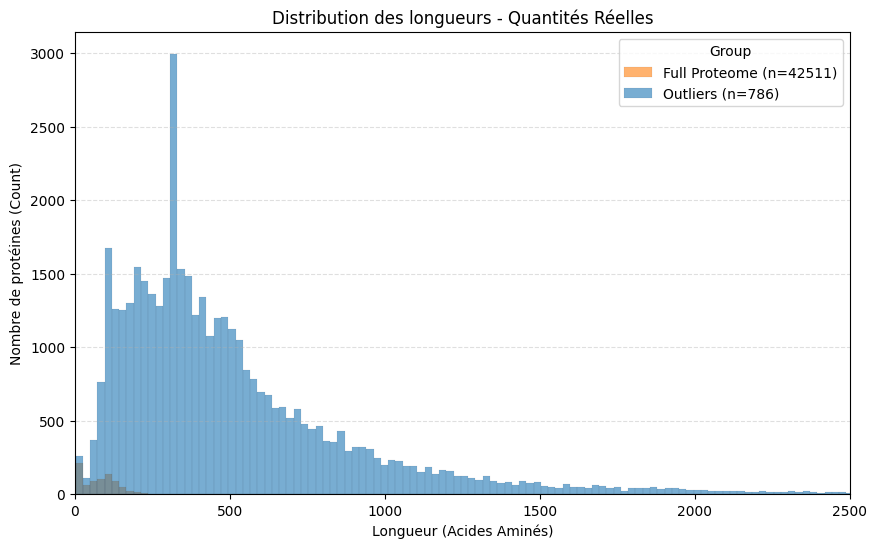

In [38]:
# 1. Extraction des données
outlier_lengths = [all_lengths_dict[pid] for pid in unique_outliers if pid in all_lengths_dict]
proteome_lengths = list(all_lengths_dict.values())

# 2. Construction du DataFrame
df_plot = pd.concat([
    pd.DataFrame({'Length': proteome_lengths, 'Group': 'Full Proteome'}),
    pd.DataFrame({'Length': outlier_lengths, 'Group': 'Outliers (Max-Pooling)'})
])

# 3. Statistiques descriptives
total_p = len(proteome_lengths)
total_o = len(outlier_lengths)
perc_o = (total_o / total_p) * 100

print(f"Moyenne Proteome  : {np.mean(proteome_lengths):.1f} AA")
print(f"Moyenne Outliers  : {np.mean(outlier_lengths):.1f} AA")

# 4. Plot en mode "Quantités Réelles"
plt.figure(figsize=(10, 6))

# On utilise stat="count" (par défaut) pour voir les vraies quantités
sns.histplot(data=df_plot, x="Length", hue="Group", 
             element="bars", 
             stat="count", 
             common_norm=False,
             palette=['#1f77b4', '#ff7f0e'],
             alpha=0.6)

plt.xlim(0, 2500)
plt.title("Distribution des longueurs - Quantités Réelles")
plt.xlabel("Longueur (Acides Aminés)")
plt.ylabel("Nombre de protéines (Count)")

# Petit ajout pour la clarté dans ton rapport : une légende avec les effectifs
plt.legend(title='Group', labels=[f'Full Proteome (n={total_p})', f'Outliers (n={total_o})'])

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [41]:
def embedding_setup(path):
    ids = []
    embeddings = []

    with h5py.File(path, "r") as hf:
        for sequenceID in hf.keys():
            dataset = hf[sequenceID]
            # 1. On crée un array vide de la bonne taille en Float32
            # dataset.shape te donne la dimension du vecteur (ex: 1024)
            vec = np.empty(dataset.shape, dtype='float32')
            
            # 2. On force la lecture directe dedans
            dataset.read_direct(vec)
            
            ids.append(sequenceID)
            embeddings.append(vec)
            
    # On empile tout à la fin
    embed_array = np.array(embeddings).astype('float32')
    
    return ids, embed_array
# have to use this function twice : once on query once on reference

In [42]:
def extractname_frompath(organismpath) :
    filename = os.path.basename(organismpath)
    nomseul = os.path.splitext(filename)[0]
    label= nomseul.split('_')[0]

    return label

In [43]:
def index_search_distances_cosine(emb_query,emb_ref):
  
    
    faiss.normalize_L2(emb_query)
    faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = 1024  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatIP(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [45]:
path_Org1_cosine = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/mouse_embeddings_maxpooling.h5"
path_Org2_cosine = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/human_embeddings_maxpooling.h5"

In [46]:

id1c,emb1c = embedding_setup(path_Org1_cosine)
id2c,emb2c = embedding_setup(path_Org2_cosine)
    
label1 = extractname_frompath(path_Org1_cosine)
label2 = extractname_frompath(path_Org2_cosine)

distances1_2c, indices1_2c= index_search_distances_cosine(emb1c,emb2c)
distances2_1c, indices2_1c= index_search_distances_cosine(emb2c, emb1c)
    # run the function twice to get all the closest neighbor

all_closest_neighborsc = np.concatenate([distances1_2c.flatten(),distances2_1c.flatten()])


neighbor_names_2_1c = [id1c[idx[0]] for idx in indices2_1c]
neighbor_names_1_2c = [id2c[idx[0]] for idx in indices1_2c]


df1c = pd.DataFrame({'proteinID' : id1c, 'closest_Neighbor' : neighbor_names_1_2c, 'similarité' : distances1_2c.flatten(), 'species' : label1  })
df2c = pd.DataFrame({'proteinID' : id2c, 'closest_Neighbor' : neighbor_names_2_1c, 'similarité' : distances2_1c.flatten(), 'species' : label2  })

df_allorganismc = pd.concat([df1c,df2c],ignore_index=True)
df_allorganismc = df_allorganismc.sort_values(by=["similarité"])

print(df_allorganismc.head(500).to_string())


                            proteinID                closest_Neighbor  similarité species
25921           sp|P0DPR3|TRDD1_HUMAN            sp|P38639|UF01_MOUSE    0.695046   human
25914           sp|P0DPI4|TDB01_HUMAN            sp|P38642|UF04_MOUSE    0.833485   human
25875           sp|P0DOY5|HD101_HUMAN            sp|P38644|UF06_MOUSE    0.842547   human
42311  tr|A0A1Y8EI39|A0A1Y8EI39_HUMAN            sp|P38644|UF06_MOUSE    0.862491   human
3294             sp|P38639|UF01_MOUSE  tr|A0A0J9YXN1|A0A0J9YXN1_HUMAN    0.869720   mouse
42312  tr|A0A1Y8EKQ5|A0A1Y8EKQ5_HUMAN            sp|P38644|UF06_MOUSE    0.871854   human
4578             sp|P83854|GPCR_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.878672   mouse
18342  tr|A0ABJ3HP72|A0ABJ3HP72_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.882023   mouse
42286  tr|A0A0J9YWD0|A0A0J9YWD0_HUMAN           sp|Q9CQD6|SARCO_MOUSE    0.882656   human
3296             sp|P38641|UF03_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.884697   mouse
3295      

In [ ]:
deviationstd_similarity = df_allorganismc['similarité'].std()
mean_similarity = df_allorganismc['similarité'].mean()

# On prend la moyenne + 3 écarts-types
outliers_cutoff = mean_similarity - (3 * deviationstd_similarity)

df_outliers_cos = df_allorganismc[df_allorganismc['similarité'] < outliers_cutoff]

print(f"Cutoff (Mean + 3std) : {outliers_cutoff:.4f}")
print(f"Nombre d'outliers identifiés : {len(df_outliers_cos)}")

Cutoff (Mean + 3std) : 0.9710
Nombre d'outliers identifiés : 786


/tmp/ipykernel_3057201/3677634927.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


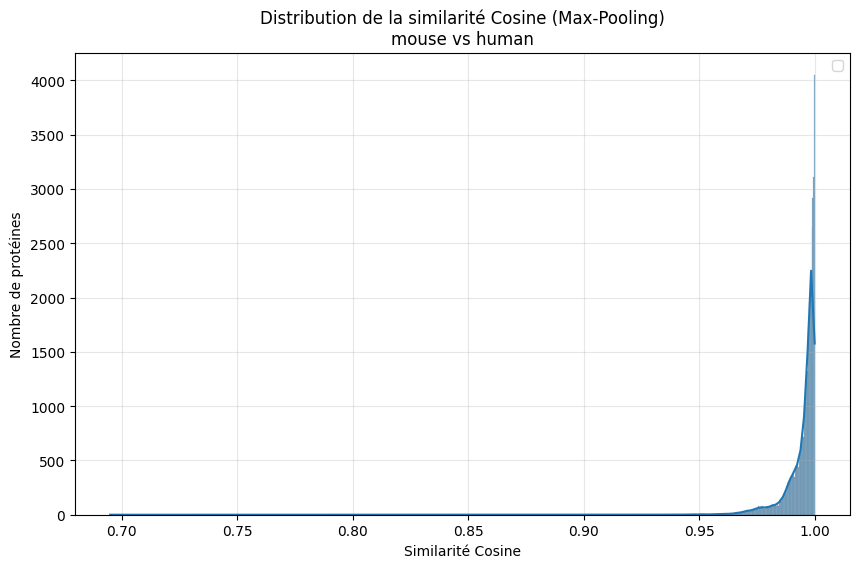

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_similarity_distribution(df, label1, label2):
    plt.figure(figsize=(10, 6))
    
    # 1. Tracer l'histogramme et la courbe de densité (KDE)
    sns.histplot(df['similarité'], kde=True)
    
    # 2. Calculer les stats pour les afficher sur le graphe
    mean_sim = df['similarité'].mean()
    std_sim = df['similarité'].std()
    cutoff = mean_sim - (3 * std_sim)
    
    
    plt.title(f'Distribution de la similarité Cosine (Max-Pooling)\n{label1} vs {label2}')
    plt.xlabel('Similarité Cosine')
    plt.ylabel('Nombre de protéines')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()

# Utilisation
plot_similarity_distribution(df_allorganismc, label1, label2)

In [ ]:
outliers1 = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/human_mouseoutliers_homosapiens.txt"
outliers2 = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_human.txt"

In [65]:
def compare_outliers(file_path_1, file_path_2):
    # 1. Charger les IDs dans des sets (pour la vitesse et les opérations mathématiques)
    with open(file_path_1, 'r') as f:
        set1 = {line.strip() for line in f if line.strip()}
    
    with open(file_path_2, 'r') as f:
        set2 = {line.strip() for line in f if line.strip()}

    # 2. Calculer l'intersection (l'overlap)
    overlap = set1.intersection(set2)
    
    # 3. Calculer ce qui est spécifique à chaque fichier
    only_in_1 = set1 - set2
    only_in_2 = set2 - set1

    # 4. Affichage des résultats
    print(f"--- COMPARAISON DES OUTLIERS ---")
    print(f"Fichier 1 ({file_path_1.split('/')[-1]}) : {len(set1)} IDs")
    print(f"Fichier 2 ({file_path_2.split('/')[-1]}) : {len(set2)} IDs")
    print("-" * 30)
    print(f"Overlap (IDs communs) : {len(overlap)}")
    
    if len(overlap) > 0:
        print(f"Exemples d'overlap : {list(overlap)[:5]}")
        
    # Calcul du pourcentage d'overlap (Indice de Jaccard)
    if len(set1 | set2) > 0:
        jaccard = len(overlap) / len(set1 | set2) * 100
        print(f"Indice de similitude : {jaccard:.2f}%")

# Chemins vers tes fichiers (adapte si besoin)
outliers1 = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/human_mouseoutliers_mus.txt"
outliers2 = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_mouse.txt"

compare_outliers(outliers1, outliers2)

--- COMPARAISON DES OUTLIERS ---
Fichier 1 (human_mouseoutliers_mus.txt) : 635 IDs
Fichier 2 (outliers_mouse.txt) : 278 IDs
------------------------------
Overlap (IDs communs) : 143
Exemples d'overlap : ['A0A991EQU4', 'P38642', 'P38640', 'P60897', 'D3Z4U6']
Indice de similitude : 18.57%
